# Hamming's Proof of Noise Growth under Application of the Discrete Derivative

<br>
<br>

<center>
Mauro J. Sanchirico III

May 7 2026
</center>

<br>
<br>

*This is an educational notebook intended to demonstrate the well-known impacts of discrete derivatives on noisy time series data. Well-known textbook insights from the great Richard Hamming are further exposited with steps expanded and numerical examples included.*

<br>
<br>

---

## Introduction

The discrete derivative, defined here by the forward difference operator,
$$
\Delta f(x) = f(x+h) - f(x),
$$
must be used with caution in algorithm design, due to its well-known tendency to amplify noise. When the discrete derivative is applied to a noisy time series, the noise component of the time series will be amplified, while the signal component will tend towards zero for many practical applications. Consider, for example, a time series which represents the position of an object in the physical world. It is likely that position of the object as a function of time is easily represented as a polynomial over a short time window. The discrete derivatives of a polynomial will tend towards zero (as the continuous derivatives will), but as we will see, the noise component will be amplified by a factor of
$$
\binom{2k}{k}
=
\frac{(2k)!}{(k!)^2}
$$
where $k$ is the order of the discrete derivative taken.

Here we analyze how noise power increases with respect to the number of discrete derivatives taken of a time series and present numerical examples. While there are a number of ways to approach this analysis, we take a random variable algebra approach, following Hamming's explanation in Chapter 2 of Numerical Methods for Scientists and Engineers. We further exposit Hamming's explanation by starting with specific examples of first and second order differences, and computing the result for a generic function with errors,
$$
f(x) = \varphi(x) + \eta(x),
$$
then computing the power caused by the noise term $\eta(x)$. We assume throughout that the errors are independently sampled from a normal distribution, $\eta(x) \sim \mathcal{N}(\mu,\sigma^2)$, having mean $\mu = \mathbb{E}[\eta(x)]$ and variance $\sigma^2 = \mathrm{Var}[\eta(x)]$. A frequency domain analysis is also  is left to a future exposition.

## Hamming on Discrete Derivatives

Hamming discusses the practical considerations on discrete derivative impacts to noise in a number of his books. *All* are recommended reading, both for exposition of difference calculus and related considerations in digital computing, and for more general engineering wisdom.

Specific references recommended to go along with this memo:

* *Numerical Methods for Scientists and Engineers - Chapter 1 - The Difference Calculus*. See the error propagation table for the difference operator.
* *Numerical Methods for Scientists and Engineers - Chapter 2 - Roundoff Noise*. This is the derivation we follow here for the amount of noise in the $k$th discrete derivative.
* *The Art of Doing Science and Engineering - Chapters 14-17 - Digital Filters I-IV*. See the explanation of the difference operator in the frequency domain in Digital Filters III and the story about noisy data series (and initial resistance to the idea of applying filters to non-time-series data) in Digital Filters IV.

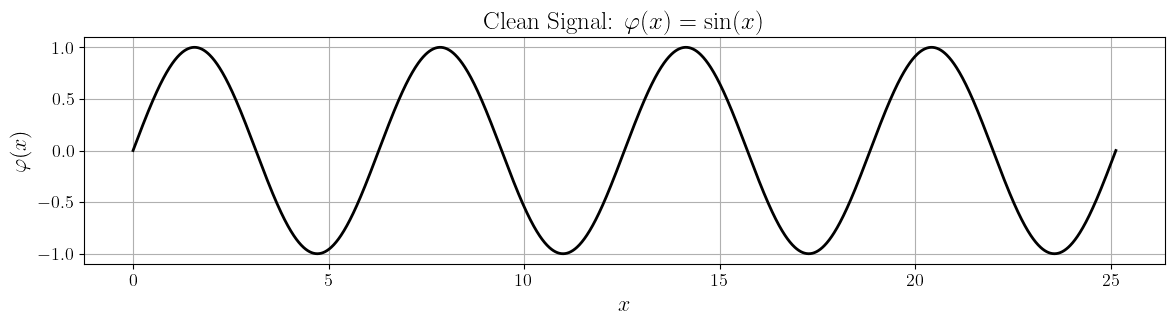

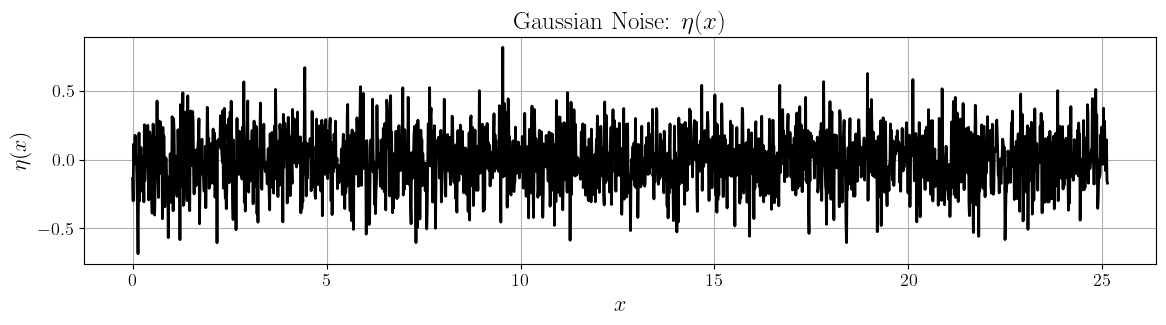

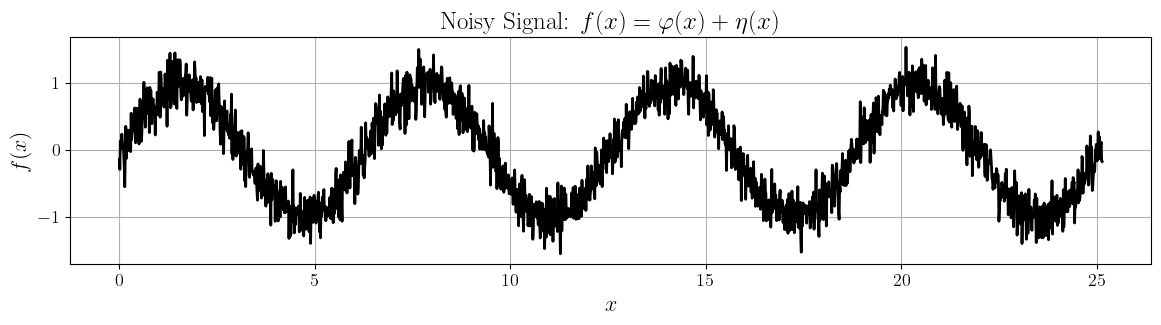

Original signal power P_phi = 0.499750
Original noise power  P_eta = 0.041127


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update(
    {
        'text.usetex': True,
        'font.family': 'serif',
        'font.size': 15,
        'axes.labelsize': 16,
        'axes.titlesize': 18,
        'legend.fontsize': 14,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'figure.figsize': (10, 5),
        'lines.linewidth': 2,
        'axes.grid': True,
    }
)

# Sinusoidal example signal
N = 2000
x = np.linspace(0, 8 * np.pi, N)
phi = np.sin(x)

# Gaussian noise
mu = 0.0
sigma = 0.2
eta = np.random.normal(mu, sigma, size=N)

# Noisy signal
f = phi + eta

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x, phi, color='black')
ax.set_title(r'Clean Signal: $\varphi(x) = \sin(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\varphi(x)$')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x, eta, color='black')
ax.set_title(r'Gaussian Noise: $\eta(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$\eta(x)$')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(x, f, color='black')
ax.set_title(r'Noisy Signal: $f(x)=\varphi(x)+\eta(x)$')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$f(x)$')
plt.tight_layout()
plt.show()

# Compute signal power
P_phi = np.mean(phi**2)

# Compute noise power
P_eta = np.mean(eta**2)

print(f'Original signal power P_phi = {P_phi:.6f}')
print(f'Original noise power  P_eta = {P_eta:.6f}')

## First Difference

### Algebra of Random Variables

Substitute $f(x)=\varphi(x)+\eta(x)$ into $\Delta f(x)=f(x+h)-f(x)$. This gives

$$
\Delta f(x)
=
\left[\varphi(x+h)+\eta(x+h)\right]
-
\left[\varphi(x)+\eta(x)\right].
$$

Distribute the subtraction:

$$
\Delta f(x)
=
\varphi(x+h)-\varphi(x)
+
\eta(x+h)-\eta(x).
$$

Define $\Delta \eta(x) = \eta(x+h)-\eta(x)$ such that

$$
\Delta f(x)
=
\varphi(x+h)-\varphi(x)
+
\Delta \eta(x).
$$

Since $\eta(x+h), \eta(x)$ are independent Gaussian random variables with identical distribution, $\Delta \eta(x)=\eta(x+h)-\eta(x)$ is also Gaussian with mean $\mathbb{E}[\Delta \eta(x)] = \mu-\mu = 0$, and variance $\mathrm{Var}[\Delta \eta(x)] = \mathrm{Var}[\eta(x+h)] + \mathrm{Var}[\eta(x)] = \sigma^2+\sigma^2 = 2\sigma^2$ such that

$$
\Delta \eta(x)\sim\mathcal{N}(0,2\sigma^2).
$$

### Power Computation

For a random variable $X$, its power is given by $P_X = \mathbb{E}[X^2]$. The power of $X\sim\mathcal{N}(\mu,\sigma^2)$ is $P_X=\sigma^2+\mu^2$. Therefore,

$$
P_\eta=\sigma^2+\mu^2,
\qquad
P_{\Delta \eta}=2\sigma^2.
$$

The ratio of noise power after the discrete derivative is taken to original noise power is then given by

$$
\frac{P_{\Delta \eta}}{P_\eta}
=
\frac{2\sigma^2}{\sigma^2+\mu^2}.
$$

For zero-mean noise

$$
\frac{P_{\Delta \eta}}{P_\eta}
=
\frac{2\sigma^2}{\sigma^2}
=
2.
$$

This matches the expected result, since

$$
\frac{(2 \times 1)!}{(1!)^2} = 2.
$$




# Second Difference

The second forward difference is

$$
\Delta^2 f(x)
=
\Delta(\Delta f(x)).
$$

Using

$$
\Delta f(x)=f(x+h)-f(x),
$$

we get

$$
\Delta^2 f(x)
=
\left[f(x+2h)-f(x+h)\right]
-
\left[f(x+h)-f(x)\right].
$$

Combining terms,

$$
\Delta^2 f(x)
=
f(x+2h)-2f(x+h)+f(x).
$$

Substitute

$$
f(x)=\varphi(x)+\eta(x).
$$

Then

$$
\Delta^2 f(x)
=
\left[\varphi(x+2h)+\eta(x+2h)\right]
-
2\left[\varphi(x+h)+\eta(x+h)\right]
+
\left[\varphi(x)+\eta(x)\right].
$$

Distribute the terms:

$$
\Delta^2 f(x)
=
\varphi(x+2h)-2\varphi(x+h)+\varphi(x)
+
\eta(x+2h)-2\eta(x+h)+\eta(x).
$$

Define

$$
\Delta^2 \eta(x)
=
\eta(x+2h)-2\eta(x+h)+\eta(x).
$$

Then

$$
\Delta^2 f(x)
=
\varphi(x+2h)-2\varphi(x+h)+\varphi(x)
+
\Delta^2 \eta(x).
$$

Assume

$$
\eta(x+2h), \eta(x+h), \eta(x)
$$

are independent Gaussian random variables with distribution

$$
\mathcal{N}(\mu,\sigma^2).
$$

Then

$$
\Delta^2 \eta(x)
=
\eta(x+2h)-2\eta(x+h)+\eta(x)
$$

is Gaussian.

The mean is

$$
\mathbb{E}[\Delta^2 \eta(x)]
=
\mu-2\mu+\mu
=
0.
$$

The variance is

$$
\mathrm{Var}[\Delta^2 \eta(x)]
=
\sigma^2
+
(-2)^2\sigma^2
+
\sigma^2
=
\sigma^2+4\sigma^2+\sigma^2
=
6\sigma^2.
$$

Therefore,

$$
\Delta^2 \eta(x)
\sim
\mathcal{N}(0,6\sigma^2).
$$

The power is

$$
P_{\Delta^2 \eta}=6\sigma^2.
$$

Therefore,

$$
\frac{P_{\Delta^2 \eta}}{P_\eta}
=
\frac{6\sigma^2}{\sigma^2+\mu^2}.
$$

For zero-mean noise,

$$
\frac{P_{\Delta^2 \eta}}{P_\eta}
=
\frac{6\sigma^2}{\sigma^2}
=
6.
$$

So the second difference increases the noise power by a factor of $6$.

# Check Against Hamming's Formula

Hamming's noise amplification factor for the $k$-th difference is

$$
\binom{2k}{k}
=
\frac{(2k)!}{(k!)^2}.
$$

For the first difference, $k=1$:

$$
\binom{2}{1}=2,
\qquad
\frac{P_{\Delta \eta}}{P_\eta}=2.
$$

For the second difference, $k=2$:

$$
\binom{4}{2}
=
\frac{4!}{2!^2}
=
\frac{24}{4}
=
6,
\qquad
\frac{P_{\Delta^2 \eta}}{P_\eta}=6.
$$

The derivation matches Hamming's formula.

# The $k$-th Difference

The $k$-th forward difference is

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
f(x+nh).
$$

Writing the binomial coefficient explicitly,

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\frac{k!}{n!(k-n)!}
f(x+nh).
$$

Substitute

$$
f(x)=\varphi(x)+\eta(x)
$$

into the $k$-th difference:

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\left[
\varphi(x+nh)+\eta(x+nh)
\right].
$$

Distribute the sum:

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\varphi(x+nh)
+
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\eta(x+nh).
$$

Define

$$
\Delta^k \eta(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\eta(x+nh).
$$

Then

$$
\Delta^k f(x)
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\varphi(x+nh)
+
\Delta^k \eta(x).
$$

Assume

$$
\eta(x), \eta(x+h), \eta(x+2h), \dots, \eta(x+kh)
$$

are independent Gaussian random variables with distribution

$$
\mathcal{N}(\mu,\sigma^2).
$$

Then $\Delta^k \eta(x)$ is Gaussian.

The mean is

$$
\mathbb{E}[\Delta^k \eta(x)]
=
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
\mu.
$$

Factor out $\mu$:

$$
\mathbb{E}[\Delta^k \eta(x)]
=
\mu
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}.
$$

Using the binomial identity

$$
\sum_{n=0}^{k}
(-1)^{k-n}
\binom{k}{n}
=
0,
\qquad k\ge 1,
$$

we get

$$
\mathbb{E}[\Delta^k \eta(x)] = 0.
$$

Now compute the variance:

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sum_{n=0}^{k}
\left[
(-1)^{k-n}
\binom{k}{n}
\right]^2
\sigma^2.
$$

Factor out $\sigma^2$:

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sigma^2
\sum_{n=0}^{k}
\left[
(-1)^{k-n}
\binom{k}{n}
\right]^2.
$$

Since the sign squares away,

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sigma^2
\sum_{n=0}^{k}
\binom{k}{n}^2.
$$

Use the identity

$$
\sum_{n=0}^{k}
\binom{k}{n}^2
=
\binom{2k}{k}.
$$

Therefore,

$$
\mathrm{Var}[\Delta^k \eta(x)]
=
\sigma^2
\binom{2k}{k}.
$$

So

$$
\Delta^k \eta(x)
\sim
\mathcal{N}
\left(
0,
\sigma^2\binom{2k}{k}
\right),
\qquad k\ge 1.
$$


# Power Ratio for the $k$-th Difference

Since

$$
\Delta^k \eta(x)
\sim
\mathcal{N}
\left(
0,
\sigma^2\binom{2k}{k}
\right),
$$

the power in the $k$-th difference noise is

$$
P_{\Delta^k \eta}
=
\sigma^2\binom{2k}{k}.
$$

The original noise power is

$$
P_\eta=\sigma^2+\mu^2.
$$

Therefore,

$$
\frac{P_{\Delta^k \eta}}{P_\eta}
=
\frac{
\sigma^2\binom{2k}{k}
}{
\sigma^2+\mu^2
}.
$$

For zero-mean noise $(\mu=0)$,

$$
\frac{P_{\Delta^k \eta}}{P_\eta}
=
\frac{
\sigma^2\binom{2k}{k}
}{
\sigma^2
}
=
\binom{2k}{k}.
$$

Using the explicit form of the binomial coefficient,

$$
\frac{P_{\Delta^k \eta}}{P_\eta}
=
\frac{(2k)!}{(k!)^2}.
$$

Thus the noise amplification factor for the $k$-th difference is

$$
\boxed{
\binom{2k}{k}
=
\frac{(2k)!}{(k!)^2}
}
$$

for zero-mean independent Gaussian noise.